In [52]:

# =========================
# SIMPLE SVM IDEA FROM SCRATCH
# Non-linear → map → linear works
# =========================


In [53]:


import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


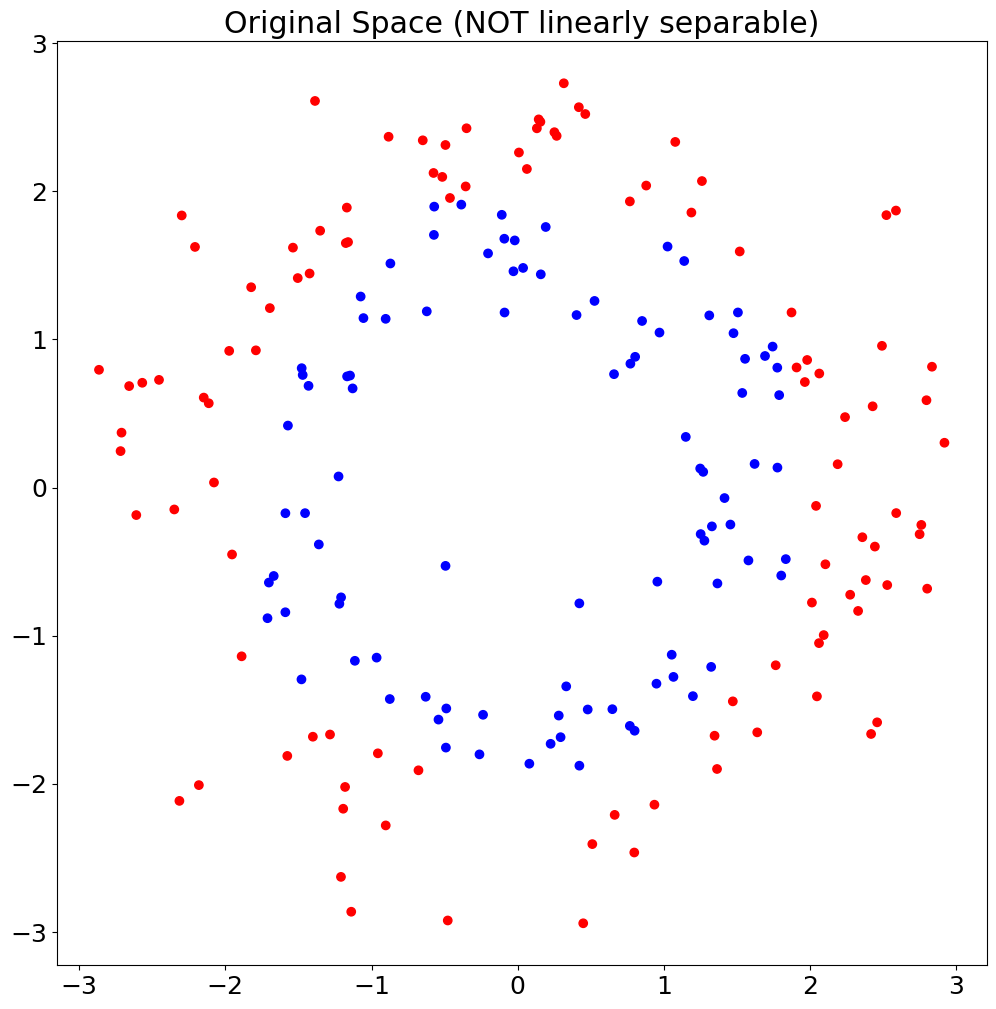

In [54]:


# -------------------------
# 1) NON-SEPARABLE DATA (circle)
# -------------------------
N = 200
r = np.random.randn(N) * 0.5 + 2
theta = np.random.rand(N) * 2 * np.pi

X = np.c_[r * np.cos(theta), r * np.sin(theta)]
y = (r > 2).astype(int) * 2 - 1   # labels: -1, +1

plt.figure()
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Original Space (NOT linearly separable)")
plt.show()


In [55]:

X.shape


(200, 2)

In [56]:

# -------------------------
# 2) FEATURE MAP (kernel idea)
# phi(x) = [x1, x2, x1^2 + x2^2]
# -------------------------
def phi(X):
    x1 = X[:,0]
    x2 = X[:,1]
    return np.c_[x1, x2, x1**2 + x2**2]


In [57]:

## Kernel mapping

X_feat = phi(X)
X_feat.shape


(200, 3)

In [58]:

# -------------------------
# 3) TRAIN SIMPLE LINEAR MODEL (hinge loss ~ SVM)
# -------------------------


W = np.zeros(X_feat.shape[1])
b = 0

lr = 0.01
lambda_reg = 0.01

W.shape


(3,)

In [59]:

for epoch in range(1000):
    for i in range(N):

        xi = X_feat[i]
        yi = y[i]

        margin = yi * ( np.dot(W, xi) + b)

        if margin < 1:
            # hinge loss update
            W = W + lr * (yi * xi - 2 * lambda_reg * W)
            b = b + lr * yi
        else:
            # only regularization
            W = W - lr * (2 * lambda_reg * W)


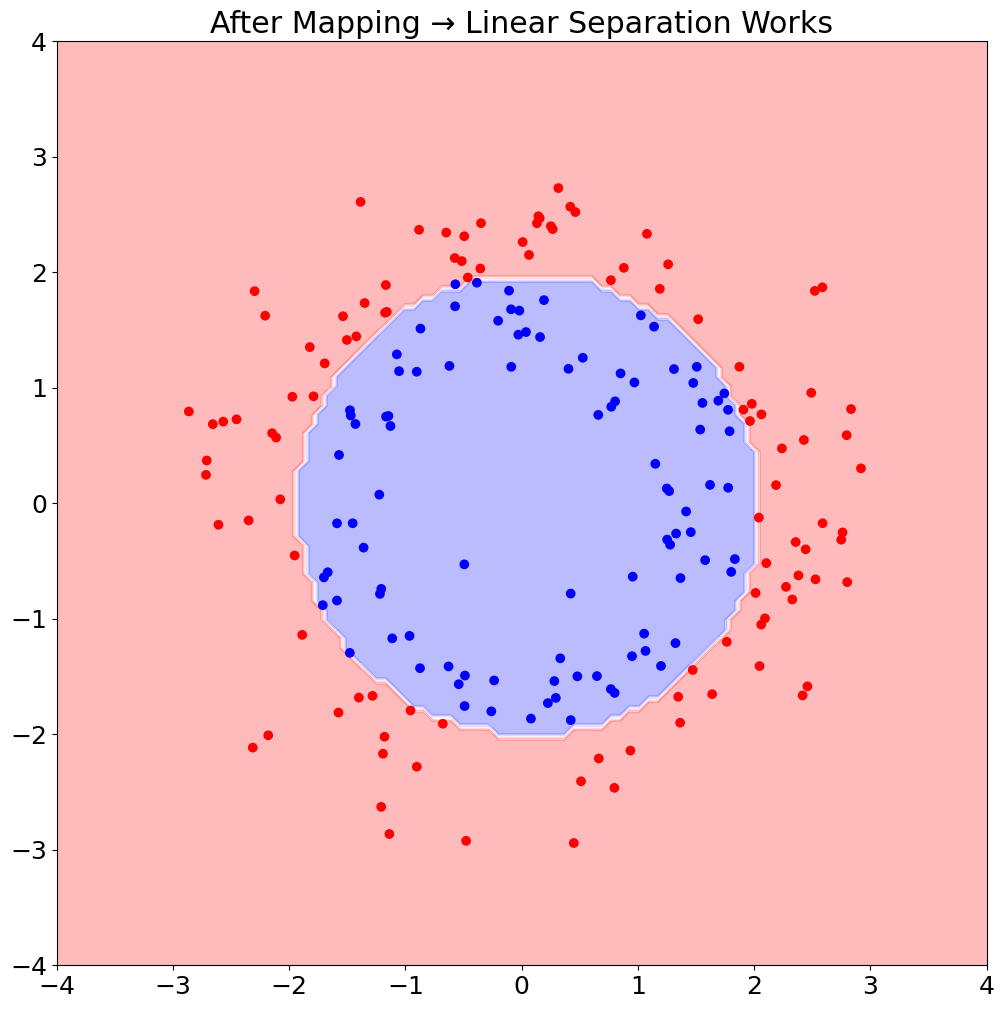

In [60]:

# -------------------------
# 4) PLOT DECISION BOUNDARY
# -------------------------
xx, yy = np.meshgrid(np.linspace(-4,4,100), np.linspace(-4,4,100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_feat = phi(grid)

Z = np.sign(grid_feat @ W + b)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("After Mapping → Linear Separation Works")
plt.show()

